In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix


In [3]:
df=pd.read_csv('car_acceptability.csv')
df

,buying price,maintenance cost,number of doors,number of persons,lug_boot,safety,evaluation
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5,5,med,med,good
1723,low,low,5,5,med,high,vgood
1724,low,low,5,5,big,low,unacc
1725,low,low,5,5,big,med,good


In [4]:
df.shape

(1727, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   buying price       1727 non-null   object
 1   maintenance cost   1727 non-null   object
 2   number of doors    1727 non-null   int64 
 3   number of persons  1727 non-null   int64 
 4   lug_boot           1727 non-null   object
 5   safety             1727 non-null   object
 6   evaluation         1727 non-null   object
dtypes: int64(2), object(5)
memory usage: 94.6+ KB


In [6]:
df.isnull().sum()

buying price         0
maintenance cost     0
number of doors      0
number of persons    0
lug_boot             0
safety               0
evaluation           0
dtype: int64

In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1722    False
1723    False
1724    False
1725    False
1726    False
Length: 1727, dtype: bool

In [8]:
df.nunique()

buying price         4
maintenance cost     4
number of doors      4
number of persons    3
lug_boot             3
safety               3
evaluation           4
dtype: int64

In [9]:

df['evaluation'].unique()

array(['unacc', 'acc', 'vgood', 'good'], dtype=object)

In [10]:
df['evaluation'].value_counts()

evaluation
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64

In [11]:
le = LabelEncoder()

df['buying price'] = le.fit_transform(df['buying price'])
df['maintenance cost'] =le.fit_transform(df['maintenance cost'])
df['lug_boot']=le.fit_transform(df['lug_boot'])
df['safety']=le.fit_transform(df['safety'])
df['evaluation']=le.fit_transform(df['evaluation'])

In [12]:
X = df.drop("evaluation",axis=1)
Y = df['evaluation']

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [14]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
Y_pred = rf.predict(X_test)

In [16]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))

Accuracy: 0.9624277456647399

Confusion Matrix:
 [[ 72   1   3   1]
 [  2  10   0   3]
 [  1   0 236   0]
 [  2   0   0  15]]


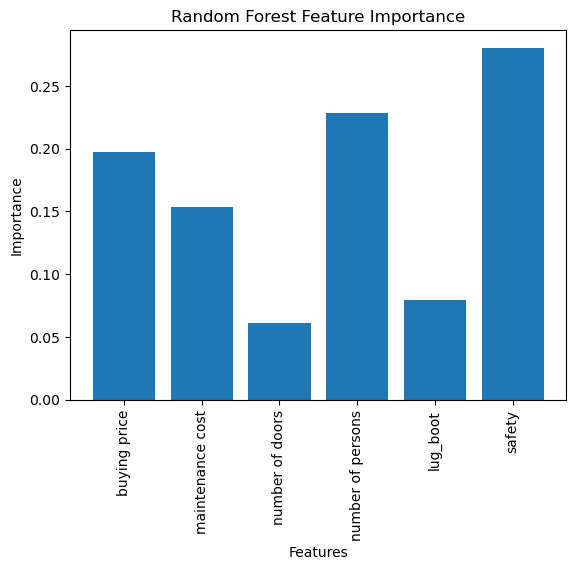

In [17]:
import matplotlib.pyplot as plt 

importance = rf.feature_importances_

plt.bar(X.columns, importance)
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()